In [19]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pwlf

In [20]:
pc1_loading_df=pd.read_csv('./RNA_DATA/pc1_sorted_weights(my data).csv')
pc1_loading_df

,gene_id,weight
0,ENSG00000213741,0.508114
1,ENSG00000228253,0.435164
2,ENSG00000198840,0.359794
3,ENSG00000166441,0.200063
4,ENSG00000075624,0.189806
...,...,...
19717,ENSG00000183795,0.000000
19718,ENSG00000187191,0.000000
19719,ENSG00000205916,0.000000
19720,ENSG00000185894,0.000000


[pwlf-logx + constrained] Elbow rank = 197
Threshold |PC1 loading|  = 0.00701187
Top genes                = 197


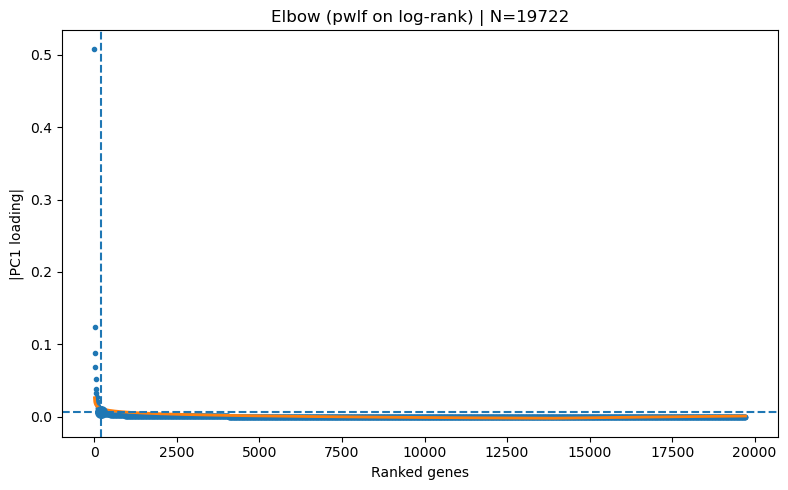

In [21]:
import numpy as np
import pwlf
import matplotlib.pyplot as plt

y = pc1_loading_df["weight"].values  # 已排序好的 |PC1 loading|
genes_sorted = pc1_loading_df["gene_id"].values
N = len(y)
x = np.arange(1, N+1, dtype=float)  # rank

def find_elbow_pwlf_logscan(x, y,
                            k_min_frac=0.01, k_max_frac=0.70,
                            min_k=20, tail_guard=20,
                            n_cands=80):
    """
    在 log(rank) 座標下，用 pwlf 的 fit_with_breaks 掃描合理的斷點範圍，
    以 SSE 最小者為 elbow。若掃描失敗，退回 pwlf.fit(2)。

    回傳: elbow_rank(int), model(pwlf 模型，用於畫線), x_fit(擬合用 x 座標)
    """
    N = len(y)
    x_fit = np.log1p(x)                         # log-rank 伸展前段
    # 斷點搜尋範圍：避免太前/太後
    k_min = max(min_k, int(k_min_frac * N))
    k_max = min(int(k_max_frac * N), N - tail_guard)
    k_min = max(2, min(k_min, N-2))
    k_max = max(k_min+1, k_max)

    # 幾何間距取樣候選斷點
    cands = np.unique(np.round(np.geomspace(k_min, k_max, num=n_cands)).astype(int))

    best_model, best_sse, best_b = None, np.inf, None
    for k in cands:
        br = np.array([x_fit[0], x_fit[k-1], x_fit[-1]], dtype=float)
        try:
            m = pwlf.PiecewiseLinFit(x_fit, y)
            m.fit_with_breaks(br)
            sse = np.sum((y - m.predict(x_fit))**2)
            if sse < best_sse:
                best_sse, best_model, best_b = sse, m, br[1]
        except Exception:
            continue



    # 把 log 座標斷點轉回 rank
    elbow_rank = int(np.clip(np.expm1(bp_log).round(), 1, N))
    return elbow_rank, m, x_fit

# ---- 執行尋找 elbow ----
elbow_rank, model, x_fit = find_elbow_pwlf_logscan(x, y,
                                                   k_min_frac=0.01,  # 可調：前 1%
                                                   k_max_frac=0.70,  # 可調：到 70%
                                                   min_k=20, tail_guard=20,
                                                   n_cands=80)

elbow_threshold = y[elbow_rank - 1]
elbow_genes = genes_sorted[:elbow_rank]

print(f"[pwlf-logx + constrained] Elbow rank = {elbow_rank}")
print(f"Threshold |PC1 loading|  = {elbow_threshold:.6g}")
print(f"Top genes                = {len(elbow_genes)}")

# ---------- 視覺化 ----------
step = max(1, N // 2000)
x_plot, y_plot = x[::step], y[::step]

xhat = np.linspace(1, N, 2000)
yhat = model.predict(np.log1p(xhat))

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, 'o', ms=3)
plt.plot(xhat, yhat, '-', lw=2)
plt.axvline(elbow_rank, ls='--')
plt.axhline(elbow_threshold, ls='--')
plt.scatter([elbow_rank], [elbow_threshold], s=70, zorder=5)
plt.title(f"Elbow (pwlf on log-rank) | N={N}")
plt.xlabel("Ranked genes")
plt.ylabel("|PC1 loading|")
plt.tight_layout()
plt.show()


[pwlf-PiecewiseLinFit] Elbow rank = 197
Threshold |PC1 weighting|    = 0.00701187
Top genes                  = 197


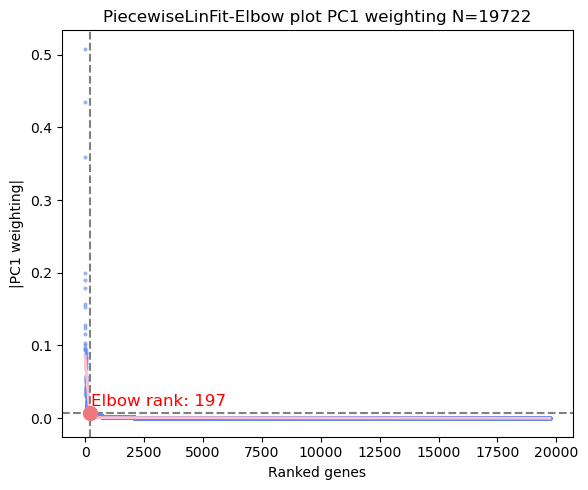

In [60]:
import numpy as np
import pandas as pd
import pwlf
import matplotlib.pyplot as plt

# 讀已排序好的 |PC1 loading|
pc1_loading_df = pd.read_csv("./RNA_DATA/pc1_sorted_weights(my data).csv")
y = pc1_loading_df["weight"].values          # 已按絕對值由大到小
genes_sorted = pc1_loading_df["gene_id"].values
N = len(y)
x = np.arange(1, N+1, dtype=float)          # 線性 rank：1..N

# 1) 設定斷點搜尋範圍（線性 x）
k_min = max(20, int(0.01 * N))    # 斷點下限＝max(20, N的1%)，避免太靠前
k_max = min(int(0.7 * N), N-20)   # 斷點上限＝min(0.7N, N-20)，避免太靠尾
k_min = max(2, min(k_min, N-2))
k_max = max(k_min+1, k_max)

# 幾何間距取樣（前段更密集），你也可改成 np.linspace 做等距
candidates = np.unique(np.round(np.geomspace(k_min, k_max, 100)).astype(int))
#從k_min~k_max取100個點

best_model, best_sse, best_breakpoint = None, np.inf, None
#最佳模型、最佳誤差(先設無線大)、最佳斷點
for k in candidates:
    br = np.array([x[0], x[k-1], x[-1]], dtype=float) 
    #x[0]:Rank最小值 x[k-1]:當前斷點 x[-1]:Rank最大值 ->2段線
    try:
        m = pwlf.PiecewiseLinFit(x, y)
        m.fit_with_breaks(br)
        sse = np.sum((y - m.predict(x))**2)
        if sse < best_sse:
            best_model, best_sse, best_breakpoint  = m, sse, br[1]
    except Exception: #擬合失敗
        continue
m = best_model
bp = best_breakpoint 

elbow_rank = int(np.clip(round(bp), 1, N)) #np.clip 限制在 [1, N] 範圍內
elbow_threshold = y[elbow_rank-1]
elbow_genes = genes_sorted[:elbow_rank]

print(f"[pwlf-PiecewiseLinFit] Elbow rank = {elbow_rank}")
print(f"Threshold |PC1 weighting|    = {elbow_threshold:.6g}") #.g:general format
print(f"Top genes                  = {len(elbow_genes)}")

# 視覺化
xhat = np.linspace(1, N, 2000)
yhat = m.predict(xhat)

plt.figure(figsize=(6,5))
plt.plot(x, y, 'o', ms=2, alpha=0.5,color='#6188F0')
plt.plot(xhat, yhat, '-', lw=2,color='pink')
plt.axvline(elbow_rank, ls='--',color='grey')
plt.axhline(elbow_threshold, ls='--',color='grey')
plt.scatter([elbow_rank],[elbow_threshold], s=100, zorder=5,color='#EF777F') #zorder圖層順序(越大越前)
plt.text(elbow_rank+50, elbow_threshold+0.005,
         f"Elbow rank: {elbow_rank}",
         fontsize=12, color="red", ha="left", va="bottom")
plt.title(f"PiecewiseLinFit-Elbow plot PC1 weighting N={N}")
plt.xlabel("Ranked genes")
plt.ylabel("|PC1 weighting|")
plt.tight_layout()
plt.show()

